# Exploratory Data Analysis 

## Podstawowe informacje o danych

Wczytanie i szybki podgląd struktur

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

DATA_PATH = "../data/raw/produkcja.csv"
FAILURE_COLS = ["TWF", "HDF", "PWF", "OSF", "RNF"]

def load_data(path=DATA_PATH):
    return pd.read_csv(path)

def show_basic_info(df):
    print(f"Is Null: {df.isnull().any().any()}")
    print(f"Shape: {df.shape}")
    display(df.dtypes)

def failure_stats_by_type(df):
    counts = pd.crosstab(df["Type"], df["Machine failure"])
    rates = pd.crosstab(df["Type"], df["Machine failure"], normalize="index") * 100
    return counts, rates.round(2)

def filter_cofailures(df, failure_cols=None, min_count=2):
    cols = failure_cols or FAILURE_COLS
    return df[df[cols].sum(axis=1) >= min_count]

def plot_box_hist(df, flag_col, value_col, palette="Set3"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.boxplot(
        x=flag_col,
        y=value_col,
        hue=flag_col,
        data=df,
        palette=palette,
        ax=axes[0],
        legend=False,
    )
    axes[0].set_title(f"Wykres pudełkowy {flag_col} vs {value_col}")

    sns.histplot(data=df, x=value_col, hue=flag_col, kde=True, ax=axes[1])
    axes[1].set_title(f"Histogram {value_col}")

    plt.tight_layout()
    plt.show()

def plot_violin_hist(df, flag_col, value_col, palette="Set3"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.violinplot(
        x=flag_col,
        y=value_col,
        hue=flag_col,
        data=df,
        palette=palette,
        ax=axes[0],
        legend=False,
    )
    axes[0].set_title(f"Wykres wiolinowy {flag_col} vs {value_col}")

    sns.histplot(data=df, x=value_col, hue=flag_col, kde=True, ax=axes[1])
    axes[1].set_title(f"Histogram {value_col}")

    plt.tight_layout()
    plt.show()

def add_temperature_difference(df):
    df_out = df.copy()
    df_out["roznica_temp"] = df_out["Process temperature [K]"] - df_out["Air temperature [K]"]
    return df_out

def power(df):
    df_out = df.copy()
    df_out["Power"] = df_out["Torque [Nm]"] * df_out["Rotational speed [rpm]"] * 0.10472
    return df_out

df = load_data()
df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


Sprawdzenie kompletności zbioru, rozmiar bazy danych oraz typy danych

In [2]:
show_basic_info(df)

Is Null: False
Shape: (10000, 14)


UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Generowanie statystyk opisowych

In [3]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Sprawdzanie ilości awarii

In [4]:
df[df["Machine failure"] == 1].value_counts()

UDI   Product ID  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF
51    L47230      L     298.9                309.1                    2861                    4.6          143              1                0    0    1    0    0      1
70    L47249      L     298.9                309.0                    1410                    65.7         191              1                0    0    1    1    0      1
78    L47257      L     298.8                308.9                    1455                    41.3         208              1                1    0    0    0    0      1
161   L47340      L     298.4                308.2                    1282                    60.7         216              1                0    0    0    1    0      1
162   L47341      L     298.3                308.1                    1412                    52.3         218              1                0    0    0   

Sprawdzanie maszyn danego typu

In [5]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Sprawdzanie awarii po typie maszyny

In [6]:
df[df['Machine failure'] == 1]['Type'].value_counts()

Type
L    235
M     83
H     21
Name: count, dtype: int64

In [7]:
crosstab, awaryjnosc = failure_stats_by_type(df)

display(crosstab)
display(awaryjnosc)

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


Machine failure,0,1
Type,,
H,97.91,2.09
L,96.08,3.92
M,97.23,2.77


## Wykresy i analiza

Sprawdzanie zależności między awarią a temperaturą/tool wear

C:\Users\kknap\AppData\Local\Temp\ipykernel_19024\2416102454.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kknap\AppData\Local\Temp\ipykernel_19024\2416102454.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


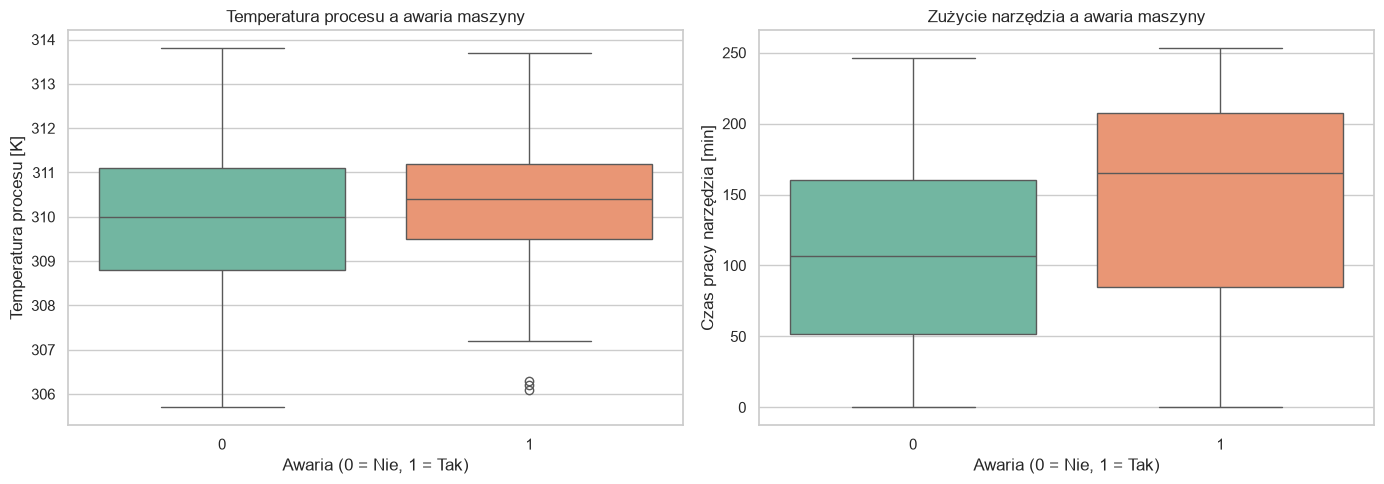

In [8]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    ax = axes[0],
    x = "Machine failure",
    y = "Process temperature [K]",
    data = df,
    palette = "Set2"
)
# Wykres 1: Rozkład temperatur procesu w zależności od awarii maszyny
axes[0].set_title("Temperatura procesu a awaria maszyny")
axes[0].set_xlabel("Awaria (0 = Nie, 1 = Tak)")
axes[0].set_ylabel("Temperatura procesu [K]")

# Wykres 2: Rozkład zużycia narzędzia w zależności od awarii maszyny
sns.boxplot(
    ax = axes[1],
    x = "Machine failure",
    y = "Tool wear [min]",
    data = df,
    palette = "Set2"
)
axes[1].set_title("Zużycie narzędzia a awaria maszyny") 
axes[1].set_xlabel("Awaria (0 = Nie, 1 = Tak)")
axes[1].set_ylabel("Czas pracy narzędzia [min]")

plt.tight_layout()
plt.show()

Rozbicie awarii na modele maszyn

Budowa i wizualizacja macierzy korelacji

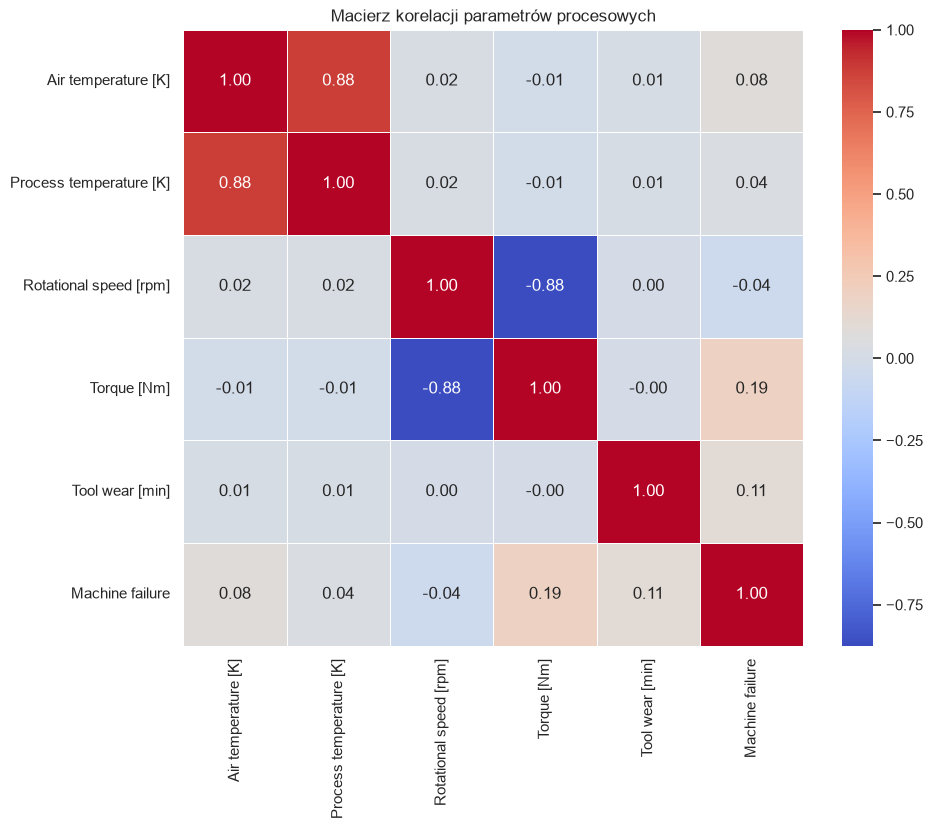

In [9]:
numeric_cols = df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']]

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Macierz korelacji parametrów procesowych")
plt.show()


Sprawdzenie zależności między typem maszyny a powodem awarii

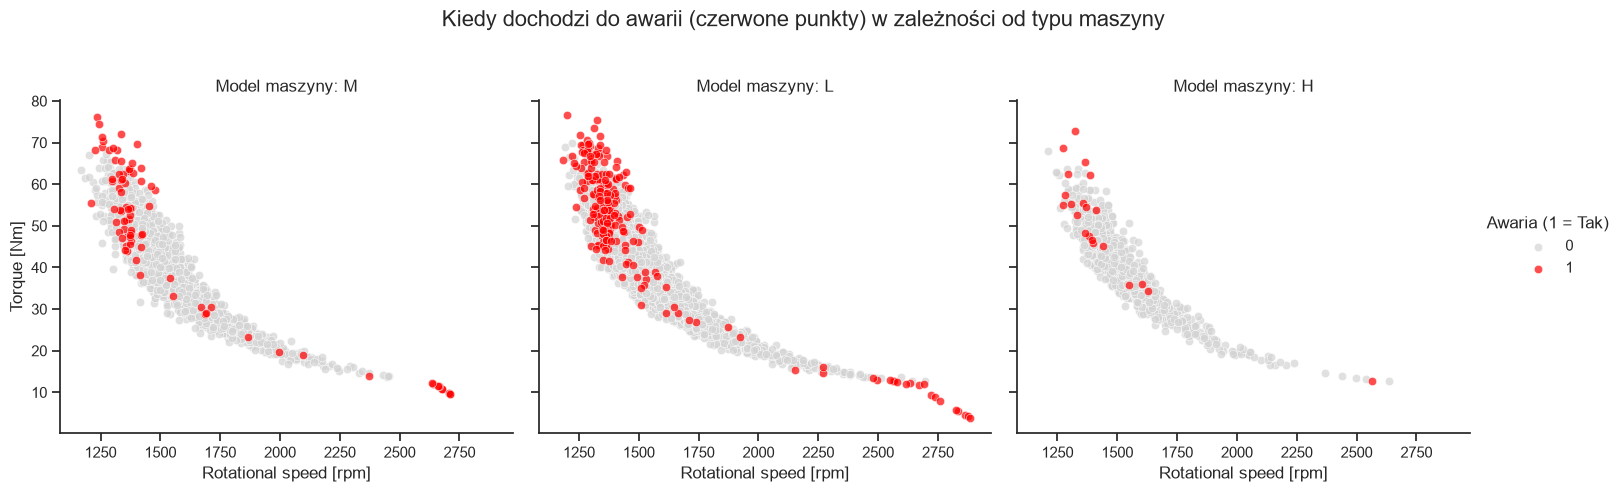

In [10]:
sns.set_theme(style="ticks")

g = sns.FacetGrid(df, col="Type", hue="Machine failure", palette={0: "lightgray", 1: "red"}, height=5, aspect=1)

g.map(sns.scatterplot, "Rotational speed [rpm]", "Torque [Nm]", alpha=0.7)

g.add_legend(title="Awaria (1 = Tak)")
g.set_titles("Model maszyny: {col_name}")
plt.subplots_adjust(top=0.8)
g.fig.suptitle("Kiedy dochodzi do awarii (czerwone punkty) w zależności od typu maszyny", fontsize=16)

plt.show()

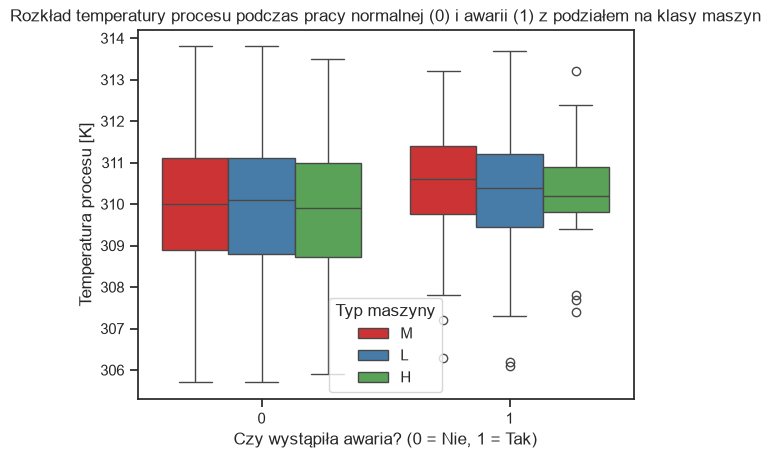

In [11]:
sns.boxplot(x="Machine failure", y = "Process temperature [K]", hue = "Type", data=df, palette="Set1")

plt.title('Rozkład temperatury procesu podczas pracy normalnej (0) i awarii (1) z podziałem na klasy maszyn')
plt.xlabel('Czy wystąpiła awaria? (0 = Nie, 1 = Tak)')
plt.ylabel('Temperatura procesu [K]')
plt.legend(title="Typ maszyny")
plt.show()


Sprawdzenie jakie rodzaje awarii nękają poszczególne typy maszyny

In [12]:
kolumny_awarii = ["Machine failure", *FAILURE_COLS]
df.groupby("Type")[kolumny_awarii].sum()

,Machine failure,TWF,HDF,PWF,OSF,RNF
Type,,,,,,
H,21,7,8,5,2,4
L,235,25,76,59,87,13
M,83,14,31,31,9,2


Wyniki: najczęstszym powodem awarii maszyny jest Heat Distribution Failure nie zależnie od rodzaju maszyny

Sprawdzanie współwystępowania awarii

In [13]:
cofail_2 = filter_cofailures(df, min_count=2)
cofail_3 = filter_cofailures(df, min_count=3)

print(f"Ilość rekordów (>=2 awarie): {cofail_2.shape[0]}")
display(cofail_2)
display(cofail_3)

Ilość rekordów (>=2 awarie): 24


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,0,0,1,1,0
1324,1325,M16184,M,298.8,310.1,1243,74.5,194,1,0,0,1,1,0
1496,1497,L48676,L,298.0,308.7,1268,69.4,189,1,0,0,1,1,0
3611,3612,L50791,L,301.7,310.9,1405,46.4,207,1,1,0,0,0,1
3854,3855,L51034,L,302.4,311.0,1338,67.6,194,1,0,0,1,1,0
3943,3944,L51123,L,302.3,311.4,1333,66.7,205,1,0,0,1,1,0
4254,4255,L51434,L,302.6,311.0,1284,68.0,114,1,0,1,1,0,0
4342,4343,M19202,M,301.7,309.8,1284,68.2,111,1,0,1,1,0,0
4370,4371,L51550,L,302.0,309.9,1308,57.6,197,1,0,1,0,1,0
4383,4384,L51563,L,301.7,309.5,1298,65.5,229,1,0,1,0,1,0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
5909,5910,H35323,H,300.7,310.2,1364,65.3,208,1,1,0,1,1,0


### Sprawdzanie zależności między parametrami w TWF za pomocą wykresów

1. Sprawdzamy zależność między parametrem Tool Wear [min] a awarią TWF za pomocą wykresu pudełkowego i histogramu

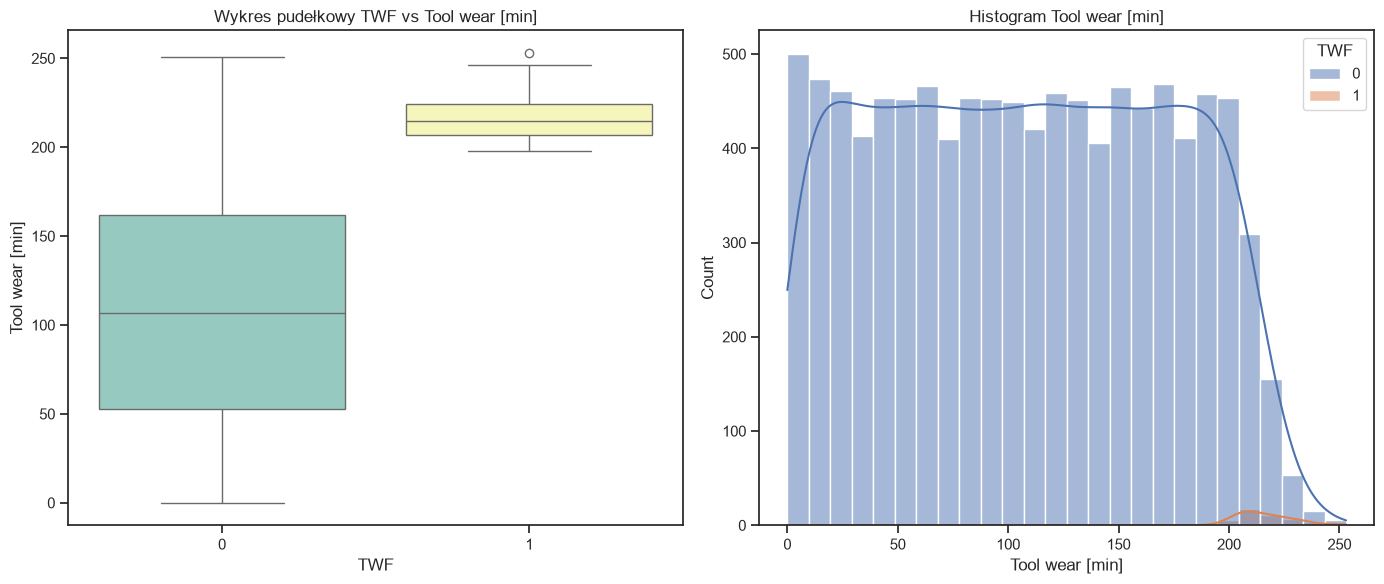

In [28]:
plot_box_hist(df, "TWF", "Tool wear [min]")

**Obserwacja:** 

TWF występuje gdy Tool wear [min] należy do przedziału [200, 250]

2. Sprawdzamy zależność między parametrem Rotational speed [rpm] a awarią TWF za pomocą wykresu pudełkowego i histogramu

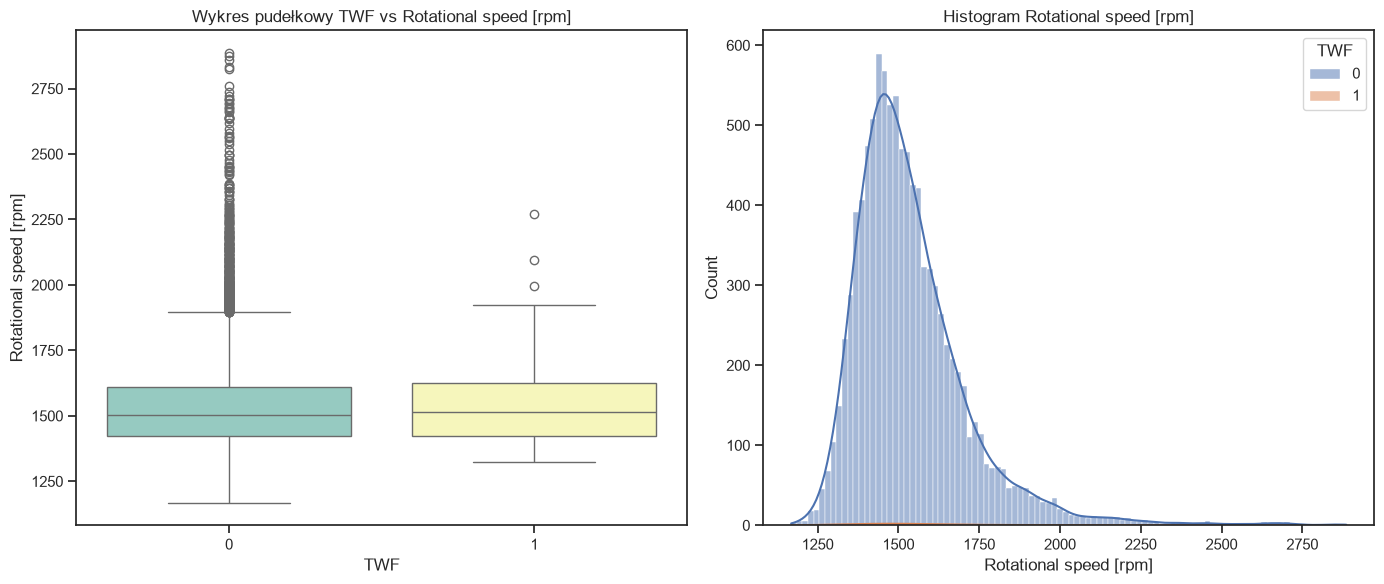

In [29]:
plot_box_hist(df, "TWF", "Rotational speed [rpm]")

**Obserwacja:**

Nie zaobserwowano zależności między Rotational speed [rpm] a TWF na podstawie przedstawionych wykresów

3. Sprawdzamy zależność między parametrem Torque [Nm] a awarią TWF za pomocą wykresu pudełkowego i histogramu

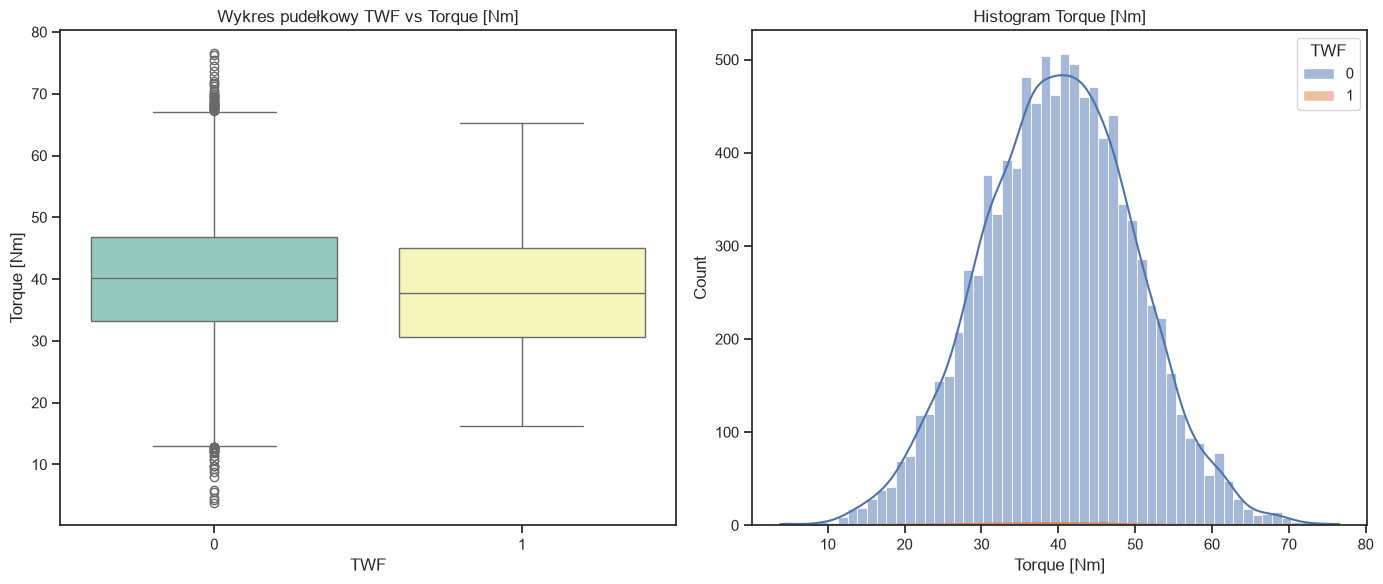

In [30]:
plot_box_hist(df, "TWF", "Torque [Nm]")

**Obserwacja:**

Nie zaobserwowano zależności między parametrem Torque [Nm] a awarią TWF na podstawie przedstawionych wykresów

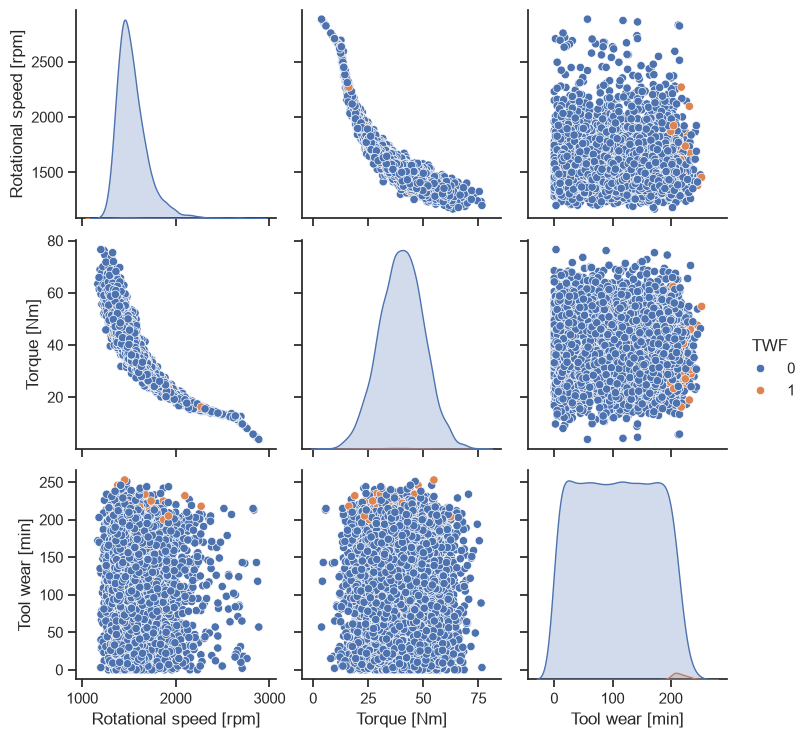

In [31]:
sns.pairplot(df[['Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF']], hue='TWF')

.


### Sprawdzanie zależności między parametrami w HDF za pomocą wykresów

1. Sprawdzamy zależność między parametrem "roznica_temp" a awarią HDF za pomocą wykresu pudełkowego i histogramu

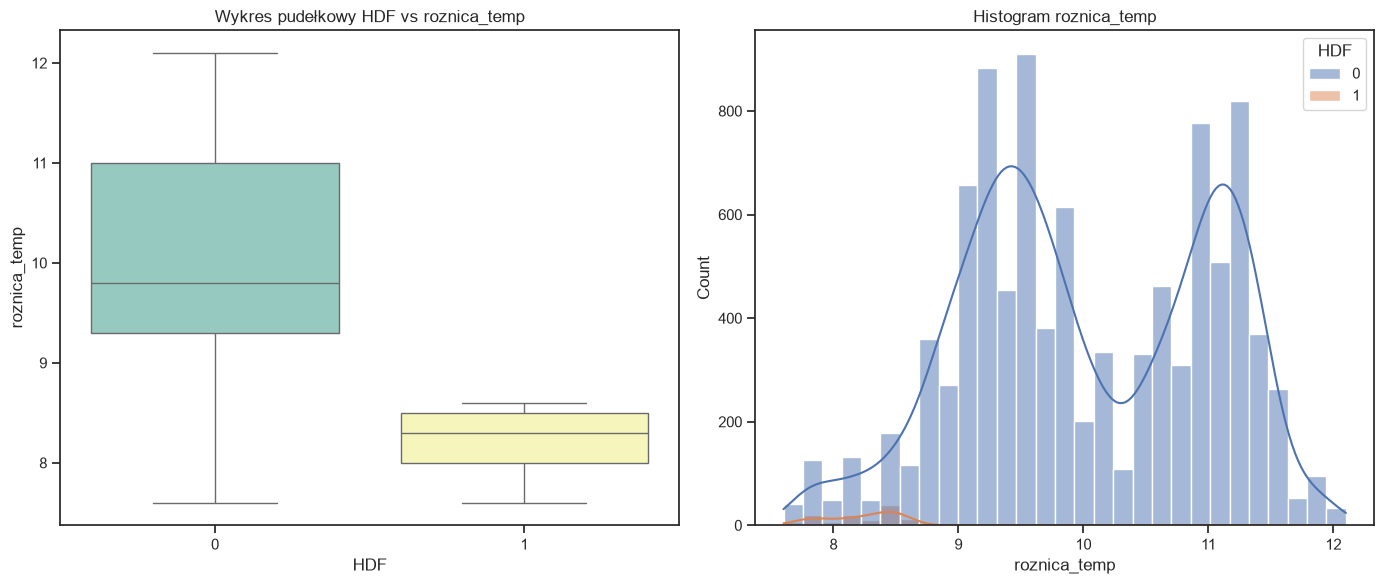

In [32]:
df_temp = add_temperature_difference(df)
plot_box_hist(df_temp, "HDF", "roznica_temp")

**Obserwacja:**

HDF występuje gdy różnica temperatur między Air temperature [K], a Process temperature [K] należy do przedziału [7,5;8,5]

2. Sprawdzamy zależność między parametrem Rotational speed [rpm], a awarią HFD za pomocą wykresu pudełkowego i histogramu

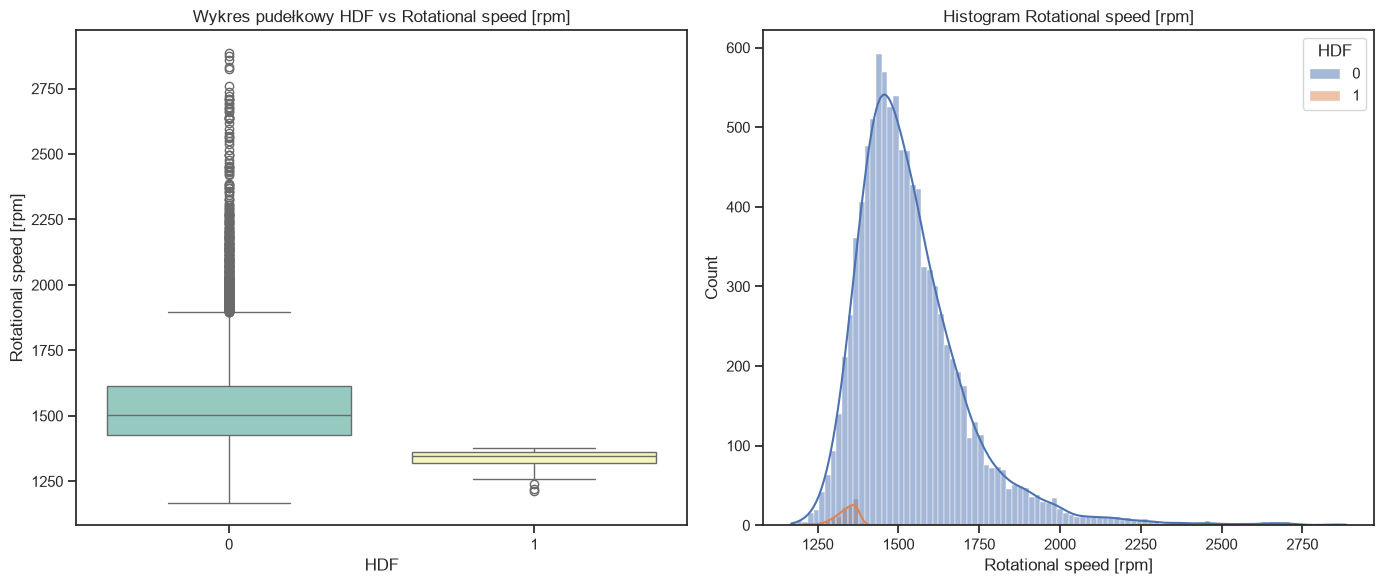

In [33]:
plot_box_hist(df, "HDF", "Rotational speed [rpm]")

**Obserwacja:**

HDF występuje gdy Rotational speed [rpm] należy do przedziału [1250,1400]

**Wnioski:**

Analiza wykazała, że awaria HDF występuje wyłącznie wtedy, gdy Rotational speed [rpm] znajduje się w przedziale 1250-1400 jednocześnie z różnicą temperatur w przedziale 7,5-8,5 K
Oznacza to, że ich równoczesne wystąpienie prowadzi do awarii HDF.

### Sprawdzanie zależności między Power, a awarią PWF za pomocą wykresu wiolinowego oraz histogramu

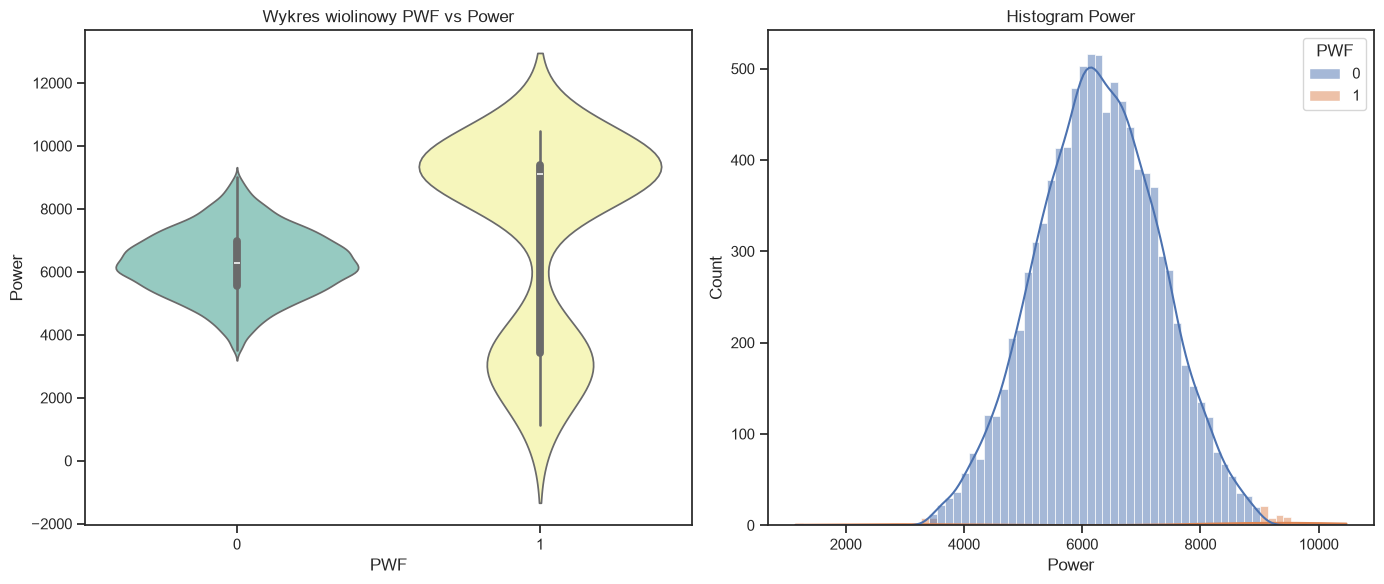

In [34]:
df_power = add_power(df)
plot_violin_hist(df_power, "PWF", "Power")

**Obserwacja:**

Przyczynowość awarii PWF wykazuje charakterystykę dwumodalną na przedziałach (0,3500] i [7000,10500)

**Wnioski:**

Moc ma dwumodalny wpływ na awarie PWF. Ryzyko wzrasta zarówno przy zbyt niskiej mocy (0–3500), jak i przy przeciążeniu (7000–10500). Przedział 3500–7000 stanowi optymalną, bezpieczną strefę pracy maszyny, którą należy utrzymywać, aby minimalizować ryzyko wystąpienia PWF.

### Sprawdzenie zależności między parametrami a awarią OSF za pomocą wykresu w przestrzeni wielowymiarowej

Obliczenie wartości progowej

In [35]:
# 1. Tworzymy zmienną będącą iloczynem obu parametrów
df['OSF_indicator'] = df['Tool wear [min]'] * df['Torque [Nm]']

# 2. Szukamy wartości minimalnej dla przypadków, w których wystąpiła awaria (OSF == 1)
threshold_estimated = df[df['OSF'] == 1]['OSF_indicator'].min()
print(f"Wyznaczona wartość progowa to około: {threshold_estimated}")

Wyznaczona wartość progowa to około: 11003.199999999999


Narysowanie wykresu zależności Power, Torque [Nm] i Tool wear [min] w przestrzeni wielowymiarowej

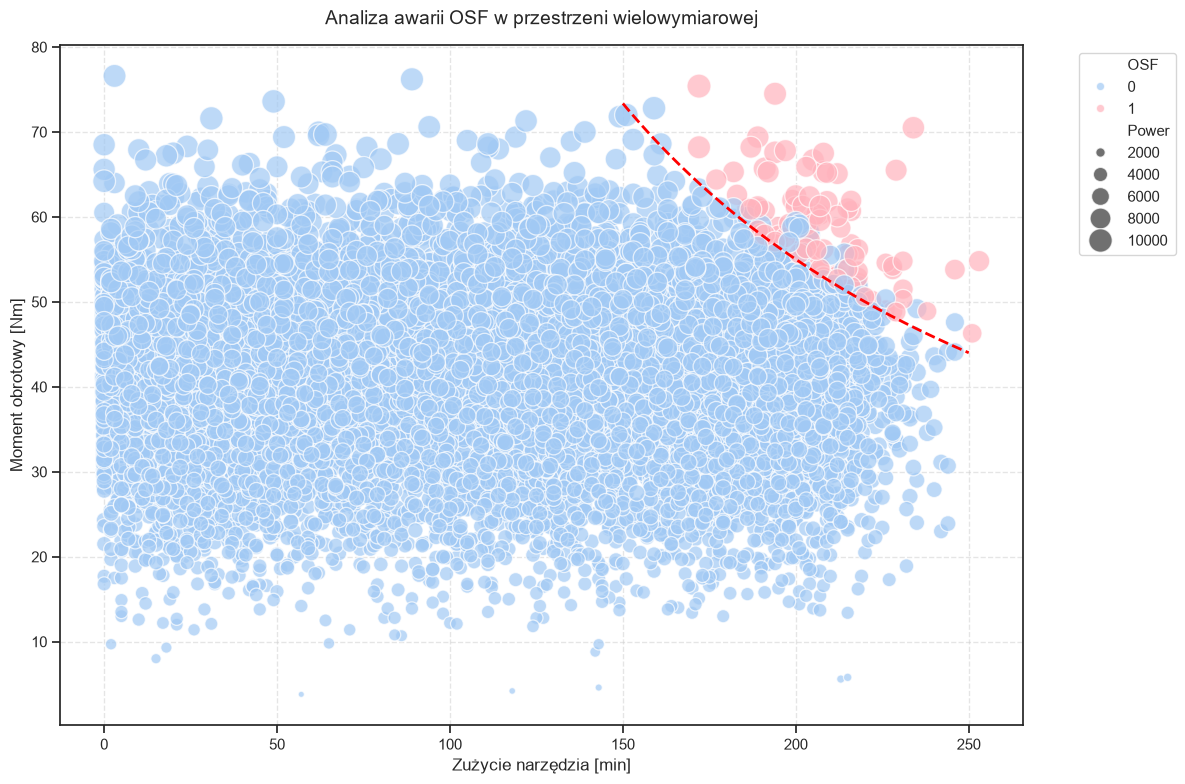

In [36]:
df["Power"] = df["Torque [Nm]"] * (df["Rotational speed [rpm]"] * 2 * 3.14159 / 60)

# 2. Tworzymy wykres
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x="Tool wear [min]",
    y="Torque [Nm]",
    hue="OSF",           # Kolor kropki zależy od awarii (0 lub 1)
    size="Power",        # Wielkość kropki zależy od wygenerowanej mocy
    sizes=(20, 300),     # Zakres wielkości kropek (minimalna i maksymalna)
    alpha=0.7,
    palette={0: "#a1c9f4", 1: "#ffb3bd"} # ładne, kontrastowe kolory
)

plt.title("Analiza awarii OSF w przestrzeni wielowymiarowej", fontsize=14, pad=15)
plt.xlabel("Zużycie narzędzia [min]", fontsize=12)
plt.ylabel("Moment obrotowy [Nm]", fontsize=12)

# Przesunięcie legendy na bok, żeby nie zasłaniała danych
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

# Generujemy punkty dla osi X (czas zużycia narzędzia od 150 do 250 min)
x_line = np.linspace(150, 250, 100)
threshold = threshold_estimated  
y_line = threshold / x_line

# Dorzucamy czerwoną linię przerywaną do wykresu
plt.plot(x_line, y_line, color="red", linestyle="--", linewidth=2, label="Teoretyczna granica OSF")
plt.tight_layout()
plt.show()